In [1]:
import os
import sys
from pathlib import Path

PROJECT_ROOT = Path(os.path.abspath(".."))
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = Path(os.path.abspath("."))

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

DATA_DIR = PROJECT_ROOT / "data"
MODELS_DIR = PROJECT_ROOT / "models"
RESULTS_DIR = PROJECT_ROOT / "results"

In [2]:
RESEARCH_DATASET_DIR = (PROJECT_ROOT / "data" / "research_processed_smoke_auto").resolve()
RESEARCH_MODEL_DIR = (PROJECT_ROOT / "models" / "research_smoke_auto").resolve()
RESEARCH_RESULTS_DIR = (PROJECT_ROOT / "results" / "research_smoke_auto").resolve()

# 01 Build Dataset

This notebook builds the multivariate FiLM autoencoder dataset directly from the raw Alibaba archives:
- `container_meta.tar.gz`
- `container_usage.tar.gz`
- `machine_meta.tar.gz`
- `machine_usage.tar.gz`

`container_usage` is the main multivariate time-series source. Container metadata and machine-level data are used as context.

In [3]:
import matplotlib.pyplot as plt
import pandas as pd

from src.config import DatasetConfig
from src.dataset import (
    CONTAINER_META_COLUMNS,
    MACHINE_META_COLUMNS,
    MACHINE_USAGE_COLUMNS,
    ContextEncoder,
    align_usage_with_context,
    build_dataset,
    clean_container_meta,
    clean_machine_meta,
    clean_machine_usage,
    generate_sliding_windows,
    inspect_raw_archives,
    load_filtered_archive,
    load_container_usage_subset,
)
from src.utils import read_json

## Configuration

In [4]:
cfg = DatasetConfig(
    raw_data_dir=DatasetConfig().raw_data_dir,
    output_dir=RESEARCH_DATASET_DIR,
    container_limit=None,
    max_usage_rows=1_000_000,
    max_container_meta_rows=None,
    max_machine_usage_rows=1_000_000,
    max_machine_meta_rows=None,
    window_size=30,
    stride=5,
)
cfg.to_dict()

{'raw_data_dir': 'C:\\Users\\kaspe\\Desktop\\Project\\dataset\\data',
 'output_dir': 'C:\\Users\\kaspe\\Desktop\\Project\\project\\data\\research_processed_smoke_auto',
 'container_meta_name': 'container_meta.tar.gz',
 'container_usage_name': 'container_usage.tar.gz',
 'machine_meta_name': 'machine_meta.tar.gz',
 'machine_usage_name': 'machine_usage.tar.gz',
 'chunksize': 10000,
 'max_usage_rows': 1000000,
 'max_container_meta_rows': None,
 'max_machine_usage_rows': 1000000,
 'max_machine_meta_rows': None,
 'container_limit': None,
 'window_size': 30,
 'stride': 5,
 'train_ratio': 0.8,
 'val_ratio': 0.0,
 'min_window_observed_ratio': 0.6,
 'feature_columns': ('cpu_util',
  'mem_util',
  'cpi',
  'mem_gps',
  'mpki',
  'net_in',
  'net_out',
  'disk_io'),
 'container_context_numeric': ('container_cpu_request',
  'container_cpu_limit',
  'container_mem_size'),
 'container_context_categorical': ('container_app_du', 'container_status'),
 'machine_context_numeric': ('machine_cpu_num',
  'ma

## Raw Data Loading From tar.gz

In [5]:
archive_status = {
    name: path.exists()
    for name, path in cfg.archive_paths.items()
}
archive_status

{'container_meta': True,
 'container_usage': True,
 'machine_meta': True,
 'machine_usage': True}

In [6]:
raw_schema = inspect_raw_archives(cfg)
raw_schema["container_usage"]

{'archive': 'C:\\Users\\kaspe\\Desktop\\Project\\dataset\\data\\container_usage.tar.gz',
 'member': 'container_usage.csv',
 'columns': ['container_id',
  'machine_id',
  'time_stamp',
  'cpu_util',
  'mem_util',
  'cpi',
  'mem_gps',
  'mpki',
  'net_in',
  'net_out',
  'disk_io'],
 'sample_rows': [{'container_id': '',
   'machine_id': 'm_108',
   'time_stamp': '696330',
   'cpu_util': '20',
   'mem_util': '56',
   'cpi': '',
   'mem_gps': '',
   'mpki': '',
   'net_in': '0',
   'net_out': '0',
   'disk_io': '2'},
  {'container_id': '',
   'machine_id': 'm_108',
   'time_stamp': '698570',
   'cpu_util': '14',
   'mem_util': '64',
   'cpi': '1.56',
   'mem_gps': '0',
   'mpki': '0',
   'net_in': '0',
   'net_out': '0',
   'disk_io': '4'},
  {'container_id': '',
   'machine_id': 'm_108',
   'time_stamp': '698620',
   'cpu_util': '12',
   'mem_util': '64',
   'cpi': '1.46',
   'mem_gps': '0.03',
   'mpki': '0',
   'net_in': '0',
   'net_out': '0',
   'disk_io': '4'},
  {'container_id': ''

## Schema Inspection

In [7]:
pd.DataFrame(
    {
        "archive": list(raw_schema.keys()),
        "columns": [schema["columns"] for schema in raw_schema.values()],
        "member": [schema["member"] for schema in raw_schema.values()],
    }
)

,archive,columns,member
0,container_meta,"[container_id, machine_id, time_stamp, app_du,...",container_meta.csv
1,container_usage,"[container_id, machine_id, time_stamp, cpu_uti...",container_usage.csv
2,machine_meta,"[machine_id, time_stamp, failure_domain_1, fai...",machine_meta.csv
3,machine_usage,"[machine_id, time_stamp, cpu_util, mem_util, m...",machine_usage.csv


## Preprocessing

In [8]:
usage_df, container_ids, machine_ids = load_container_usage_subset(cfg)

container_meta_df = load_filtered_archive(
    cfg.archive_paths["container_meta"],
    column_names=CONTAINER_META_COLUMNS,
    chunksize=cfg.chunksize,
    cleaner=clean_container_meta,
    filter_column="container_id",
    allowed_ids=container_ids,
    max_rows=cfg.max_container_meta_rows,
)
machine_usage_df = load_filtered_archive(
    cfg.archive_paths["machine_usage"],
    column_names=MACHINE_USAGE_COLUMNS,
    chunksize=cfg.chunksize,
    cleaner=clean_machine_usage,
    filter_column="machine_id",
    allowed_ids=machine_ids,
    max_rows=cfg.max_machine_usage_rows,
)
machine_meta_df = load_filtered_archive(
    cfg.archive_paths["machine_meta"],
    column_names=MACHINE_META_COLUMNS,
    chunksize=cfg.chunksize,
    cleaner=clean_machine_meta,
    filter_column="machine_id",
    allowed_ids=machine_ids,
    max_rows=cfg.max_machine_meta_rows,
)

aligned_df = align_usage_with_context(
    usage=usage_df,
    container_meta=container_meta_df,
    machine_usage=machine_usage_df,
    machine_meta=machine_meta_df,
)

print("container_usage rows:", len(usage_df))
print("container_meta rows:", len(container_meta_df))
print("machine_usage rows:", len(machine_usage_df))
print("machine_meta rows:", len(machine_meta_df))
aligned_df.head()

container_usage rows: 996497
container_meta rows: 5653
machine_usage rows: 183864
machine_meta rows: 3656


,container_id,machine_id,time_stamp,cpu_util,mem_util,cpi,mem_gps,mpki,net_in,net_out,...,machine_mem_gps,machine_mpki,machine_net_in,machine_net_out,machine_disk_io,machine_failure_domain_1,machine_failure_domain_2,machine_cpu_num,machine_mem_size,machine_status
0,c_1,m_2556,86610,12,88,0.98,0.64,0.0,1.22,1.15,...,0.0,0.0,0.0,0.0,0.0,259,11,96,100,USING
1,c_1,m_2556,87230,9,88,0.98,0.64,0.0,1.22,1.15,...,0.0,0.0,0.0,0.0,0.0,259,11,96,100,USING
2,c_1,m_2556,87420,12,88,0.98,0.64,0.0,1.22,1.15,...,0.0,0.0,0.0,0.0,0.0,259,11,96,100,USING
3,c_1,m_2556,87440,13,88,0.98,0.64,0.0,1.22,1.15,...,0.0,0.0,0.0,0.0,0.0,259,11,96,100,USING
4,c_1,m_2556,87710,10,88,0.98,0.64,0.0,1.22,1.15,...,0.0,0.0,0.0,0.0,0.0,259,11,96,100,USING


## Feature Selection

In [9]:
print("Feature columns:")
print(list(cfg.feature_columns))

print("\nContext columns:")
print(list(cfg.context_columns))

Feature columns:
['cpu_util', 'mem_util', 'cpi', 'mem_gps', 'mpki', 'net_in', 'net_out', 'disk_io']

Context columns:
['container_cpu_request', 'container_cpu_limit', 'container_mem_size', 'machine_cpu_num', 'machine_mem_size', 'machine_cpu_util', 'machine_mem_util', 'machine_mem_gps', 'machine_mpki', 'machine_net_in', 'machine_net_out', 'machine_disk_io', 'container_app_du', 'container_status', 'machine_failure_domain_1', 'machine_failure_domain_2', 'machine_status']


## Context Creation

In [10]:
encoder = ContextEncoder.fit(
    aligned_df,
    numeric_columns=list(cfg.container_context_numeric + cfg.machine_context_numeric),
    categorical_columns=list(cfg.container_context_categorical + cfg.machine_context_categorical),
)
encoder.to_metadata()

{'numeric_columns': ['container_cpu_request',
  'container_cpu_limit',
  'container_mem_size',
  'machine_cpu_num',
  'machine_mem_size',
  'machine_cpu_util',
  'machine_mem_util',
  'machine_mem_gps',
  'machine_mpki',
  'machine_net_in',
  'machine_net_out',
  'machine_disk_io'],
 'categorical_columns': ['container_app_du',
  'container_status',
  'machine_failure_domain_1',
  'machine_failure_domain_2',
  'machine_status'],
 'categories': {'container_app_du': ['app_1014',
   'app_1021',
   'app_1024',
   'app_1026',
   'app_1029',
   'app_1033',
   'app_1046',
   'app_1055',
   'app_1063',
   'app_1086',
   'app_1093',
   'app_1100',
   'app_1122',
   'app_1123',
   'app_1133',
   'app_1141',
   'app_1168',
   'app_1176',
   'app_1181',
   'app_1190',
   'app_1197',
   'app_1203',
   'app_1225',
   'app_1230',
   'app_1231',
   'app_1254',
   'app_1260',
   'app_1276',
   'app_1295',
   'app_1302',
   'app_131',
   'app_1315',
   'app_133',
   'app_1347',
   'app_1351',
   'app_136

## Sliding Window Generation

In [11]:
X_preview, C_preview, window_metadata_preview = generate_sliding_windows(
    aligned_df=aligned_df,
    config=cfg,
    context_encoder=encoder,
)

print("X shape:", X_preview.shape)
print("C shape:", C_preview.shape)
window_metadata_preview.head()

Sliding windows:   0%|                                                                                        …

X shape: (193617, 30, 8)
C shape: (193617, 17)


,window_id,entity_id,container_id,machine_id,start_index,end_index,start_time,end_time,container_app_du,container_status,machine_status,machine_failure_domain_1,machine_failure_domain_2,split
0,0,c_1,c_1,m_2556,0,29,86610,110070,app_5052,started,USING,259,11,train
1,1,c_1,c_1,m_2556,5,34,88160,116690,app_5052,started,USING,259,11,train
2,2,c_1,c_1,m_2556,10,39,91060,119490,app_5052,started,USING,259,11,train
3,3,c_1,c_1,m_2556,15,44,94140,134190,app_5052,started,USING,259,11,train
4,4,c_1,c_1,m_2556,20,49,97050,138140,app_5052,started,USING,259,11,train


## Train/Val/Test Split

In [12]:
split_counts = window_metadata_preview["split"].value_counts().sort_index()
split_counts

split
test      37655
train    154910
val        1052
Name: count, dtype: int64

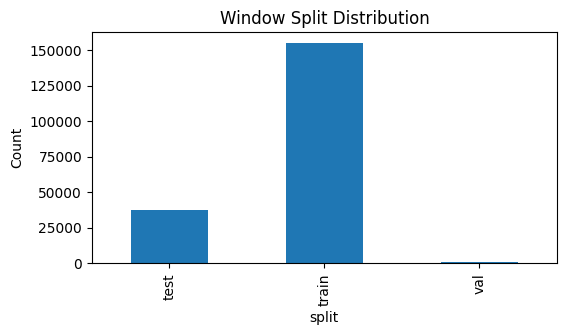

In [13]:
plt.figure(figsize=(6, 3))
split_counts.plot(kind="bar")
plt.title("Window Split Distribution")
plt.ylabel("Count")
plt.show()

## Save Artifacts To data/

In [14]:
build_summary = build_dataset(cfg)
read_json(cfg.output_dir / "dataset_build_summary.json")

Sliding windows:   0%|                                                                                        …

Final dataset shape | X_train: (154457, 30, 8)
Final dataset shape | X_test: (39160, 30, 8)


{'X_train': 'C:\\Users\\kaspe\\Desktop\\Project\\project\\data\\research_processed_smoke_auto\\X_train.npy',
 'X_test': 'C:\\Users\\kaspe\\Desktop\\Project\\project\\data\\research_processed_smoke_auto\\X_test.npy',
 'C_train': 'C:\\Users\\kaspe\\Desktop\\Project\\project\\data\\research_processed_smoke_auto\\C_train.npy',
 'C_test': 'C:\\Users\\kaspe\\Desktop\\Project\\project\\data\\research_processed_smoke_auto\\C_test.npy',
 'X_train_shape': [154457, 30, 8],
 'X_test_shape': [39160, 30, 8],
 'train_metadata': 'C:\\Users\\kaspe\\Desktop\\Project\\project\\data\\research_processed_smoke_auto\\window_metadata_train.csv',
 'test_metadata': 'C:\\Users\\kaspe\\Desktop\\Project\\project\\data\\research_processed_smoke_auto\\window_metadata_test.csv',
 'feature_meta': 'C:\\Users\\kaspe\\Desktop\\Project\\project\\data\\research_processed_smoke_auto\\feature_meta.joblib',
 'dataset_meta': 'C:\\Users\\kaspe\\Desktop\\Project\\project\\data\\research_processed_smoke_auto\\dataset_meta.json',
